In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [ ]:
data = pd.read_csv("spambase_csv.csv")

print("Dataset shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head())

print("\nMissing values:")
print(data.isnull().sum())

Dataset shape: (4601, 58)

First 5 rows:
   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  char_freq_%3B  char_freq_%28  \
0             0.00        

In [ ]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

if y.dtype == "object":
    y = y.astype("category").cat.codes

X = X.apply(pd.to_numeric, errors="coerce")

imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nClass distribution:")
print(pd.Series(y).value_counts())

Features shape: (4601, 57)
Target shape: (4601,)

Class distribution:
class
0    2788
1    1813
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3680, 57)
Testing data: (921, 57)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardization completed.")

Standardization completed.


In [ ]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(3680, 57)
(921, 57)


In [ ]:
start = time.time()

logistic_model = LogisticRegression(
    max_iter=5000
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

training_time = time.time() - start

prediction = logistic_model.predict(
    X_test_scaled
)

accuracy = accuracy_score(
    y_test,
    prediction
)

precision = precision_score(
    y_test,
    prediction,
    zero_division=0
)

recall = recall_score(
    y_test,
    prediction,
    zero_division=0
)

f1 = f1_score(
    y_test,
    prediction,
    zero_division=0
)

print("Logistic Regression")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("Training Time:", round(training_time, 4))

Logistic Regression
Accuracy : 0.9294
Precision: 0.9209
Recall   : 0.8981
F1 Score : 0.9093
Training Time: 0.0387


In [ ]:
logistic_model = LogisticRegression(
    max_iter=2000
)

logistic_parameters = [
    {
        "penalty": ["l1"],
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["liblinear"]
    },
    {
        "penalty": ["l2"],
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["liblinear"]
    },
    {
        "penalty": ["l1"],
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["saga"]
    },
    {
        "penalty": ["l2"],
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["saga"]
    }
]

start = time.time()

logistic_grid = GridSearchCV(
    logistic_model,
    logistic_parameters,
    cv=5,
    scoring="accuracy",
    n_jobs=1
)

logistic_grid.fit(
    X_train_scaled,
    y_train
)

logistic_tuning_time = time.time() - start

print("Best Parameters:")
print(logistic_grid.best_params_)

print("\nBest CV Accuracy:")
print(round(logistic_grid.best_score_, 4))

print("\nTuning Time:")
print(round(logistic_tuning_time, 4))

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

Best Parameters:
{'C': 1, 'penalty': 'l2', 'solver': 'saga'}

Best CV Accuracy:
0.9242

Tuning Time:
285.0945


In [ ]:
best_logistic = logistic_grid.best_estimator_

prediction = best_logistic.predict(
    X_test_scaled
)

accuracy = accuracy_score(
    y_test,
    prediction
)

precision = precision_score(
    y_test,
    prediction,
    zero_division=0
)

recall = recall_score(
    y_test,
    prediction,
    zero_division=0
)

f1 = f1_score(
    y_test,
    prediction,
    zero_division=0
)

print("Tuned Logistic Regression")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Tuned Logistic Regression
Accuracy : 0.9305
Precision: 0.9211
Recall   : 0.9008
F1 Score : 0.9109


In [ ]:
kernels = ["linear", "poly", "rbf", "sigmoid"]

svm_results = []

for kernel in kernels:

    start = time.time()

    svm_model = SVC(
        kernel=kernel,
        C=1,
        gamma="scale",
        degree=3
    )

    svm_model.fit(
        X_train_scaled,
        y_train
    )

    training_time = time.time() - start

    start = time.time()

    prediction = svm_model.predict(
        X_test_scaled
    )

    prediction_time = time.time() - start

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    precision = precision_score(
        y_test,
        prediction,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        prediction,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        prediction,
        zero_division=0
    )

    svm_results.append([
        kernel,
        accuracy,
        precision,
        recall,
        f1,
        training_time,
        prediction_time
    ])

    print("\nKernel:", kernel)
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("Training Time:", round(training_time, 4))
    print("Prediction Time:", round(prediction_time, 4))


Kernel: linear
Accuracy : 0.9294
Precision: 0.9209
Recall   : 0.8981
F1 Score : 0.9093
Training Time: 0.5771
Prediction Time: 0.024

Kernel: poly
Accuracy : 0.7796
Precision: 0.9598
Recall   : 0.4601
F1 Score : 0.622
Training Time: 0.5605
Prediction Time: 0.0778

Kernel: rbf
Accuracy : 0.9273
Precision: 0.9277
Recall   : 0.8843
F1 Score : 0.9055
Training Time: 0.2918
Prediction Time: 0.0853

Kernel: sigmoid
Accuracy : 0.8849
Precision: 0.8599
Recall   : 0.8457
F1 Score : 0.8528
Training Time: 0.3341
Prediction Time: 0.0558


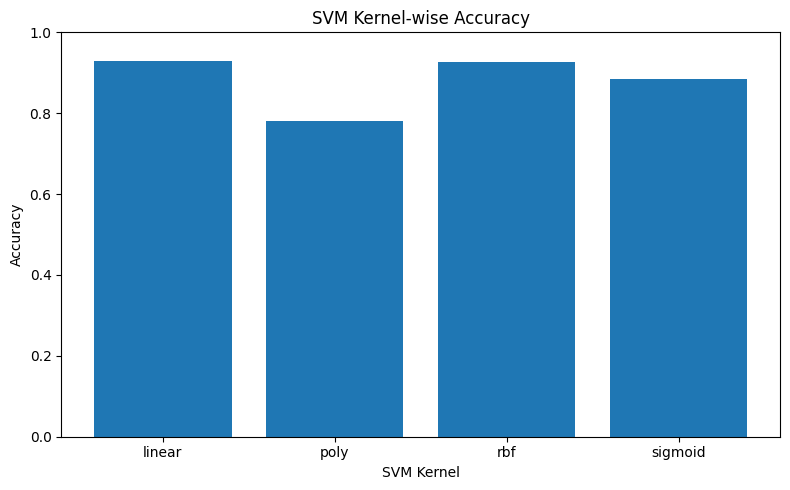

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    [x[0] for x in svm_results],
    [x[1] for x in svm_results]
)

plt.xlabel("SVM Kernel")
plt.ylabel("Accuracy")
plt.title("SVM Kernel-wise Accuracy")

plt.ylim(0, 1)

plt.tight_layout()
plt.savefig("04_svm_kernel_accuracy.png")
plt.show()

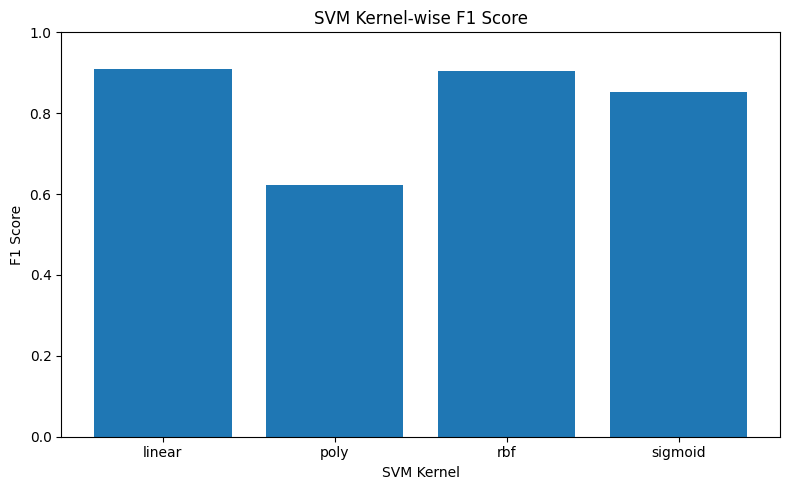

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    [x[0] for x in svm_results],
    [x[4] for x in svm_results]
)

plt.xlabel("SVM Kernel")
plt.ylabel("F1 Score")
plt.title("SVM Kernel-wise F1 Score")

plt.ylim(0, 1)

plt.tight_layout()
plt.savefig("05_svm_kernel_f1.png")
plt.show()

In [ ]:
svm_model = SVC()

svm_parameters = [
    {
        "kernel": ["linear"],
        "C": [0.1, 1, 10, 100]
    },
    {
        "kernel": ["rbf"],
        "C": [0.1, 1, 10, 100],
        "gamma": ["scale", "auto"]
    },
    {
        "kernel": ["sigmoid"],
        "C": [0.1, 1, 10, 100],
        "gamma": ["scale", "auto"]
    }
]

start = time.time()

svm_grid = GridSearchCV(
    svm_model,
    svm_parameters,
    cv=5,
    scoring="accuracy",
    n_jobs=1
)

svm_grid.fit(
    X_train_scaled,
    y_train
)

svm_tuning_time = time.time() - start

print("Best Parameters:")
print(svm_grid.best_params_)

print("Best CV Accuracy:")
print(round(svm_grid.best_score_, 4))

print("Tuning Time:")
print(round(svm_tuning_time, 4))

Best Parameters:
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy:
0.9332
Tuning Time:
117.0168


In [ ]:
best_svm = svm_grid.best_estimator_

start = time.time()

best_svm_prediction = best_svm.predict(
    X_test_scaled
)

best_svm_prediction_time = time.time() - start

best_svm_accuracy = accuracy_score(
    y_test,
    best_svm_prediction
)

best_svm_precision = precision_score(
    y_test,
    best_svm_prediction,
    zero_division=0
)

best_svm_recall = recall_score(
    y_test,
    best_svm_prediction,
    zero_division=0
)

best_svm_f1 = f1_score(
    y_test,
    best_svm_prediction,
    zero_division=0
)

print("\n======================================")
print("BEST SVM")
print("======================================")

print("Accuracy :", round(best_svm_accuracy, 4))
print("Precision:", round(best_svm_precision, 4))
print("Recall   :", round(best_svm_recall, 4))
print("F1 Score :", round(best_svm_f1, 4))
print("Prediction Time:", round(best_svm_prediction_time, 4))


BEST SVM
Accuracy : 0.9207
Precision: 0.9143
Recall   : 0.8815
F1 Score : 0.8976
Prediction Time: 0.0654


In [ ]:
print("\n======================================")
print("LOGISTIC REGRESSION VS SVM")
print("======================================")

logistic_prediction = logistic_grid.best_estimator_.predict(
    X_test_scaled
)

svm_prediction = svm_grid.best_estimator_.predict(
    X_test_scaled
)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_prediction
)

logistic_precision = precision_score(
    y_test,
    logistic_prediction,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_prediction,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_prediction,
    zero_division=0
)

svm_accuracy = accuracy_score(
    y_test,
    svm_prediction
)

svm_precision = precision_score(
    y_test,
    svm_prediction,
    zero_division=0
)

svm_recall = recall_score(
    y_test,
    svm_prediction,
    zero_division=0
)

svm_f1 = f1_score(
    y_test,
    svm_prediction,
    zero_division=0
)

print("\nTuned Logistic Regression")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1 Score :", round(logistic_f1, 4))

print("\nBest SVM")
print("Accuracy :", round(svm_accuracy, 4))
print("Precision:", round(svm_precision, 4))
print("Recall   :", round(svm_recall, 4))
print("F1 Score :", round(svm_f1, 4))


LOGISTIC REGRESSION VS SVM

Tuned Logistic Regression
Accuracy : 0.9305
Precision: 0.9211
Recall   : 0.9008
F1 Score : 0.9109

Best SVM
Accuracy : 0.9207
Precision: 0.9143
Recall   : 0.8815
F1 Score : 0.8976


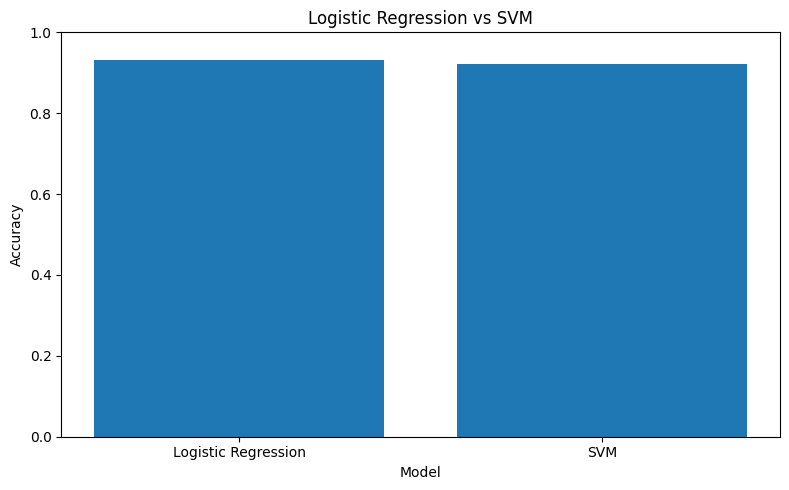

In [ ]:
models = [
    "Logistic Regression",
    "SVM"
]

accuracies = [
    logistic_accuracy,
    svm_accuracy
]

plt.figure(figsize=(8, 5))

plt.bar(
    models,
    accuracies
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Logistic Regression vs SVM")

plt.ylim(0, 1)

plt.tight_layout()
plt.savefig("06_model_comparison.png")
plt.show()

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logistic_cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        penalty=logistic_grid.best_params_["penalty"],
        C=logistic_grid.best_params_["C"],
        solver=logistic_grid.best_params_["solver"]
    ))
])

svm_cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        **svm_grid.best_params_
    ))
])

logistic_cv_scores = cross_val_score(
    logistic_cv_model,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=1
)

svm_cv_scores = cross_val_score(
    svm_cv_model,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=1
)

print("\n======================================")
print("5-FOLD CROSS VALIDATION")
print("======================================")

for i in range(5):
    print(
        "Fold", i + 1,
        "Logistic Regression:",
        round(logistic_cv_scores[i], 4),
        "SVM:",
        round(svm_cv_scores[i], 4)
    )

print("\nLogistic Regression Average:",
      round(logistic_cv_scores.mean(), 4))

print("SVM Average:",
      round(svm_cv_scores.mean(), 4))


5-FOLD CROSS VALIDATION
Fold 1 Logistic Regression: 0.9142 SVM: 0.9305
Fold 2 Logistic Regression: 0.9326 SVM: 0.9283
Fold 3 Logistic Regression: 0.9283 SVM: 0.9413
Fold 4 Logistic Regression: 0.9239 SVM: 0.9326
Fold 5 Logistic Regression: 0.9239 SVM: 0.9359

Logistic Regression Average: 0.9246
SVM Average: 0.9337


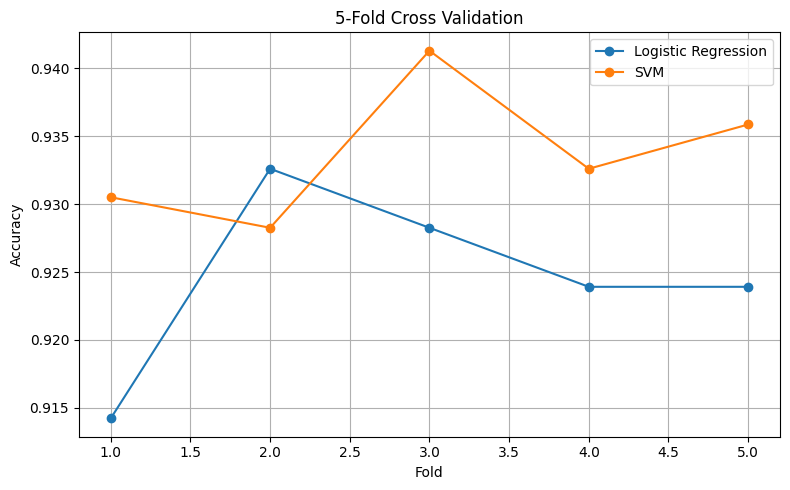

In [ ]:
folds = [1, 2, 3, 4, 5]

plt.figure(figsize=(8, 5))

plt.plot(
    folds,
    logistic_cv_scores,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    folds,
    svm_cv_scores,
    marker="o",
    label="SVM"
)

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross Validation")

plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig("07_cross_validation.png")
plt.show()

In [ ]:
final_results = pd.DataFrame(
    [
        [
            "Logistic Regression",
            logistic_accuracy,
            logistic_precision,
            logistic_recall,
            logistic_f1
        ],
        [
            "SVM",
            svm_accuracy,
            svm_precision,
            svm_recall,
            svm_f1
        ]
    ],
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

print("\n======================================")
print("FINAL RESULTS")
print("======================================")

print(
    final_results.round(4).to_string(index=False)
)


FINAL RESULTS
              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.9305     0.9211  0.9008    0.9109
                SVM    0.9207     0.9143  0.8815    0.8976


In [ ]:
cv_results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Logistic Regression": logistic_cv_scores,
    "SVM": svm_cv_scores
})

cv_results.loc[len(cv_results)] = [
    "Average",
    logistic_cv_scores.mean(),
    svm_cv_scores.mean()
]

print("\n======================================")
print("CROSS-VALIDATION RESULTS")
print("======================================")

print(
    cv_results.round(4).to_string(index=False)
)


CROSS-VALIDATION RESULTS
   Fold  Logistic Regression    SVM
      1               0.9142 0.9305
      2               0.9326 0.9283
      3               0.9283 0.9413
      4               0.9239 0.9326
      5               0.9239 0.9359
Average               0.9246 0.9337


In [ ]:
final_results.to_csv(
    "experiment4_final_results.csv",
    index=False
)

svm_results_table = pd.DataFrame(
    svm_results,
    columns=[
        "Kernel",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time",
        "Prediction Time"
    ]
)

svm_results_table.to_csv(
    "svm_kernel_results.csv",
    index=False
)

cv_results.to_csv(
    "experiment4_cv_results.csv",
    index=False
)

print("\nResults saved successfully.")


Results saved successfully.


In [ ]:
if svm_accuracy > logistic_accuracy:

    print("\n======================================")
    print("BEST PERFORMING MODEL")
    print("======================================")

    print("Model: SVM")
    print("Accuracy:", round(svm_accuracy, 4))
    print("Precision:", round(svm_precision, 4))
    print("Recall:", round(svm_recall, 4))
    print("F1 Score:", round(svm_f1, 4))
    print("Parameters:", svm_grid.best_params_)

else:

    print("\n======================================")
    print("BEST PERFORMING MODEL")
    print("======================================")

    print("Model: Logistic Regression")
    print("Accuracy:", round(logistic_accuracy, 4))
    print("Precision:", round(logistic_precision, 4))
    print("Recall:", round(logistic_recall, 4))
    print("F1 Score:", round(logistic_f1, 4))
    print("Parameters:", logistic_grid.best_params_)


BEST PERFORMING MODEL
Model: Logistic Regression
Accuracy: 0.9305
Precision: 0.9211
Recall: 0.9008
F1 Score: 0.9109
Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'saga'}


In [ ]:
print("\n======================================")
print("EXPERIMENT 4 COMPLETED")
print("======================================")

print("\nLogistic Regression Best Parameters:")
print(logistic_grid.best_params_)

print("\nLogistic Regression CV Accuracy:")
print(round(logistic_grid.best_score_, 4))

print("\nSVM Best Parameters:")
print(svm_grid.best_params_)

print("\nSVM CV Accuracy:")
print(round(svm_grid.best_score_, 4))

print("\nLogistic Regression Test Accuracy:")
print(round(logistic_accuracy, 4))

print("\nSVM Test Accuracy:")
print(round(svm_accuracy, 4))

print("\nLogistic Regression 5-Fold Average:")
print(round(logistic_cv_scores.mean(), 4))

print("\nSVM 5-Fold Average:")
print(round(svm_cv_scores.mean(), 4))


EXPERIMENT 4 COMPLETED

Logistic Regression Best Parameters:
{'C': 1, 'penalty': 'l2', 'solver': 'saga'}

Logistic Regression CV Accuracy:
0.9242

SVM Best Parameters:
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

SVM CV Accuracy:
0.9332

Logistic Regression Test Accuracy:
0.9305

SVM Test Accuracy:
0.9207

Logistic Regression 5-Fold Average:
0.9246

SVM 5-Fold Average:
0.9337
